<a href="https://colab.research.google.com/github/RMoulla/IYT_Septembre/blob/main/TP_Classification_Churn_Sep26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explication et prédiction du churn avec le machine learning

Ce TP vise à explorer et comparer différentes techniques de classification en machine learning pour expliquer et prédire le churn des clients. Le churn, ou l'attrition, est un indicateur clé pour de nombreuses entreprises ; il reflète le pourcentage de clients qui cessent d'utiliser un service sur une période donnée. Comprendre et prédire efficacement le churn peut aider les entreprises à mettre en œuvre des stratégies de rétention ciblées et à améliorer la satisfaction client.

## Le Dataset

Le dataset utilisé dans ce tutoriel contient des données sur les clients d'une entreprise, avec plusieurs caractéristiques qui pourraient influencer leur décision de rester ou de partir.

Ci-dessous un aperçu des variables incluses dans le dataset :

Names : Nom du client.

Age : Âge du client.

Total_Purchase : Montant total des achats effectués par le client.

Account_Manager : Indique si un gestionnaire de compte est assigné au client (1) ou non (0).

Years : Nombre d'années pendant lesquelles le client est avec l'entreprise.

Num_Sites : Nombre de sites utilisés par le client.

Location : Emplacement du client.

Company : Nom de l'entreprise du client.

Churn : Indique si le client a churné (1) ou non (0).

## Objectifs Spécifiques du TP

Exploration de Données : Comprendre la distribution des données, la corrélation entre les variables et le taux de churn.

Prétraitement des Données : Nettoyer et préparer les données pour la modélisation, y compris le traitement des variables catégorielles et la division des données en ensembles d'entraînement et de test.

Modélisation : Appliquer plusieurs modèles de classification, tels que la régression logistique, Random Forest et les SVM pour prédire le churn.

Évaluation des Modèles : Comparer les performances des modèles en utilisant des métriques telles que la précision, le rappel, l'accuracy et le F1.

Optimisation : Effectuer une optimisation des hyperparamètres sur les modèles sélectionnés pour améliorer leurs performances.

Interprétation : Analyser les résultats pour identifier les facteurs clés influençant le churn et discuter des implications pour les stratégies de rétention des clients.

In [ ]:
import pandas as pd

dataset = pd.read_csv('https://raw.githubusercontent.com/RMoulla/EUROSAE/main/customer_churn_clean.csv')
dataset.head(20)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1
5,Jessica Williams,48.0,10356.02,0,5.12,8.0,"6187 Olson Mountains East Vincentborough, PR 7...",Kelly-Warren,1
6,Eric Butler,44.0,11331.58,1,5.23,11.0,"4846 Savannah Road West Justin, IA 87713-3460",Reynolds-Sheppard,1
7,Zachary Walsh,32.0,9885.12,1,6.92,9.0,"25271 Roy Expressway Suite 147 Brownport, FM 5...",Singh-Cole,1
8,Ashlee Carr,43.0,14062.60,1,5.46,11.0,"3725 Caroline Stravenue South Christineview, M...",Lopez PLC,1
9,Jennifer Lynch,40.0,8066.94,1,7.11,11.0,"363 Sandra Lodge Suite 144 South Ann, WI 51655...",Reed-Martinez,1


## Analyse exploratoire des données

Nous allons commencer par une analyse exploratoire des données. Cette phase vise à comprendre les données, leur distribution et les relations entre les variables, notamment entre les variables explicatives (features) et la variable d'intérêt.

In [ ]:
# Quelques statistiques descriptives
print(dataset.describe())

              Age  Total_Purchase  Account_Manager       Years   Num_Sites  \
count  900.000000      900.000000       900.000000  900.000000  900.000000   
mean    41.816667    10062.824033         0.481111    5.273156    8.587778   
std      6.127560     2408.644532         0.499921    1.274449    1.764836   
min     22.000000      100.000000         0.000000    1.000000    3.000000   
25%     38.000000     8497.122500         0.000000    4.450000    7.000000   
50%     42.000000    10045.870000         0.000000    5.215000    8.000000   
75%     46.000000    11760.105000         1.000000    6.110000   10.000000   
max     65.000000    18026.010000         1.000000    9.150000   14.000000   

            Churn  
count  900.000000  
mean     0.166667  
std      0.372885  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      0.000000  
max      1.000000  


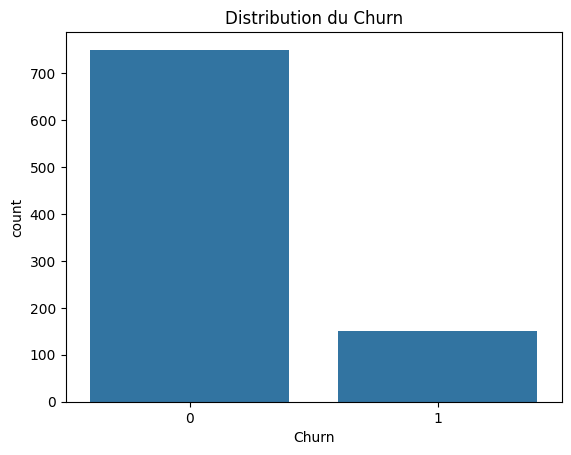

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution de la variable Churn
sns.countplot(x='Churn', data=dataset)
plt.title('Distribution du Churn')
plt.show()

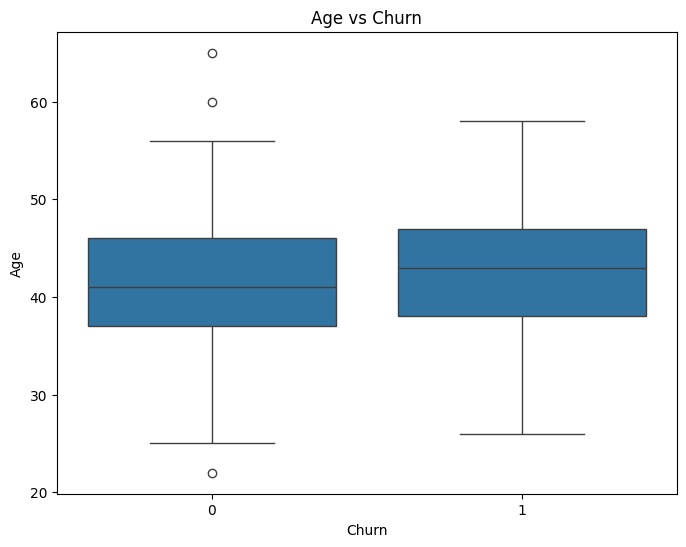

In [ ]:

# Age vs Churn
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='Age', data=dataset)
plt.title('Age vs Churn')
plt.show()

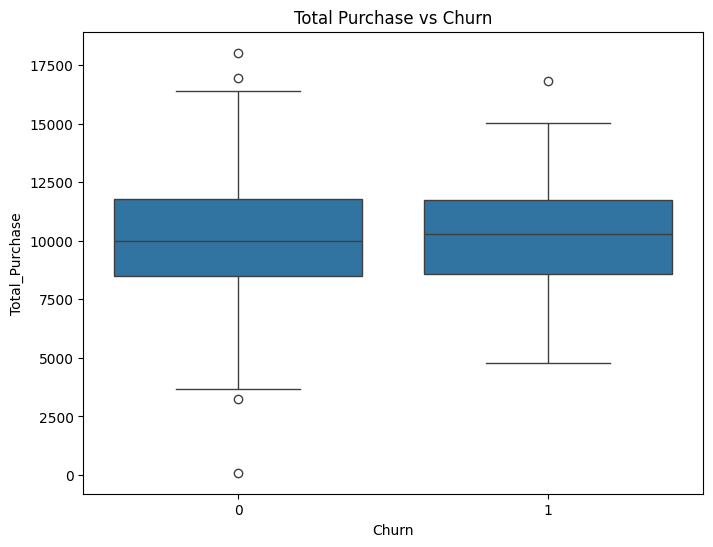

In [ ]:

# Total Purchase vs Churn
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='Total_Purchase', data=dataset)
plt.title('Total Purchase vs Churn')
plt.show()

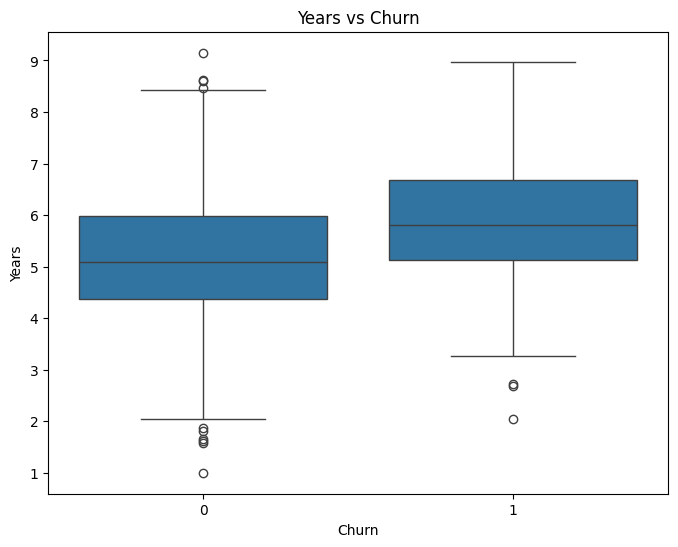

In [ ]:

# Years vs Churn
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='Years', data=dataset)
plt.title('Years vs Churn')
plt.show()

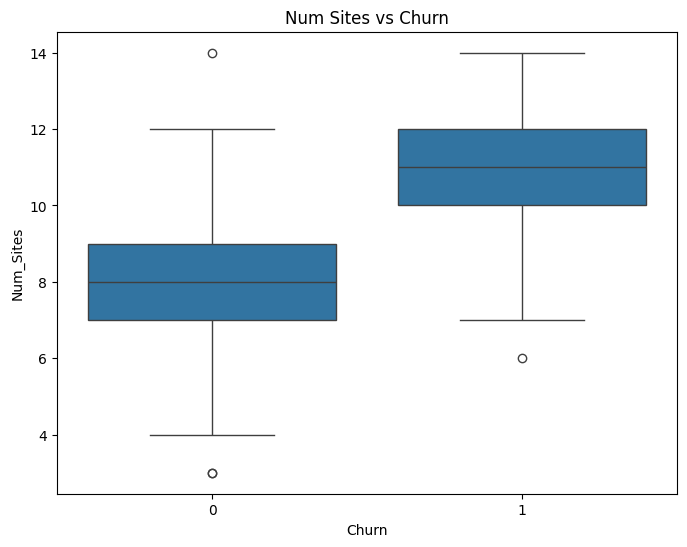

In [ ]:
plt.show()

# Num Sites vs Churn
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='Num_Sites', data=dataset)
plt.title('Num Sites vs Churn')
plt.show()

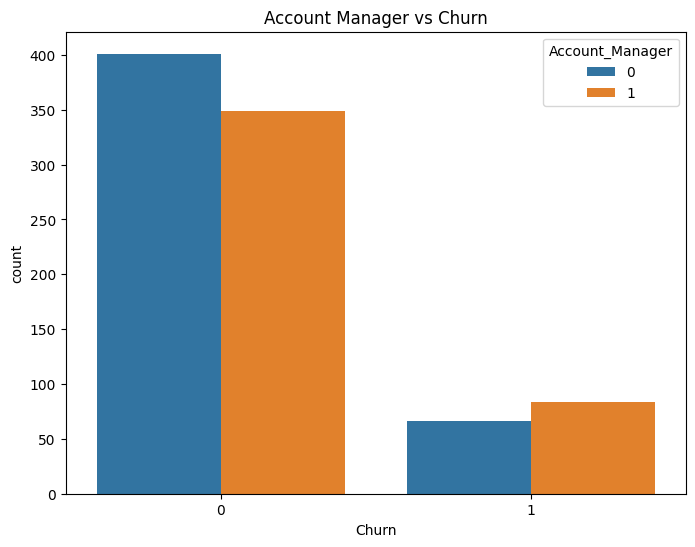

In [ ]:
# Account Manager vs Churn
plt.figure(figsize=(8, 6))
sns.countplot(x='Churn', hue='Account_Manager', data=dataset)
plt.title('Account Manager vs Churn')
plt.show()

## Modélisation

Dans cette phase, nous allons entraîner plusieurs modèles de classification, dont la régression logistique, Random Forest et, potentiellement, les SVM. Notre objectif est à la fois la compréhension des déterminants de churn et la prédiction de celui-ci.

Nous allons d'abord commencer par partitionner notre dataset en jeu de données d'entraînement et jeu de données de test.

In [ ]:
from sklearn.model_selection import train_test_split
# Partionner le dataset en train et test

features = ['Age', 'Total_Purchase', 'Account_Manager', 'Years', 'Num_Sites']
X = dataset[features]
y = dataset['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Régression logistique

In [ ]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

logit_model = sm.Logit(y_train, X_train_const)
result_sm = logit_model.fit()

result_sm.summary()

Optimization terminated successfully.
         Current function value: 0.257054
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:                  720
Model:                          Logit   Df Residuals:                      714
Method:                           MLE   Df Model:                            5
Date:                Fri, 11 Sep 2026   Pseudo R-squ.:                  0.4237
Time:                        13:39:05   Log-Likelihood:                -185.08
converged:                       True   LL-Null:                       -321.17
Covariance Type:            nonrobust   LLR p-value:                 9.559e-57
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -19.1136      1.931     -9.896      0.000     -22.899     -15.328
Age                 0.0491      0.023      2.114      0.034       0.004       0.095
Total_Purchase   3.566e-05   5.51e-05      0.647      0.518   -7.24e-05       0.000
Account_Manager     0.5457      0.269      2.030      0.042       0.019       1.072
Years               0.5278      0.107      4.939      0.000       0.318       0.737
Num_Sites           1.2499      0.115     10.839      0.000       1.024       1.476
===================================================================================
"""

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_test_pred_prob = result_sm.predict(X_test_const)

# imprimer les prédictions
print(y_test_pred_prob, '\n')

y_test_pred_sm = (y_test_pred_prob >= 0.5).astype(int)

# Calculate performance metrics using statsmodels predictions
accuracy = accuracy_score(y_test, y_test_pred_sm)
precision = precision_score(y_test, y_test_pred_sm)
recall = recall_score(y_test, y_test_pred_sm)
f1 = f1_score(y_test, y_test_pred_sm)

performance_metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
}

performance_metrics

70     0.397622
827    0.179830
231    0.019421
588    0.129233
39     0.671608
         ...   
897    0.000186
578    0.901334
779    0.014015
25     0.457460
84     0.081024
Length: 180, dtype: float64 



{'Accuracy': 0.9,
 'Precision': 0.7692307692307693,
 'Recall': 0.625,
 'F1 Score': 0.6896551724137931}

## SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# entrainer un modèle SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

performances_metrics_svm = {
    'Accuracy': accuracy_svm,
    'Precision': precision_svm,
    'Recall': recall_svm,
    'F1 Score': f1_svm
}

performances_metrics_svm

{'Accuracy': 0.8944444444444445,
 'Precision': 0.76,
 'Recall': 0.59375,
 'F1 Score': 0.6666666666666666}

## Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Entraîner un modèle random forest

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

performances_metrics_rf = {
    'Accuracy': accuracy_rf,
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1 Score': f1_rf
}

performances_metrics_rf

{'Accuracy': 0.8722222222222222,
 'Precision': 0.7368421052631579,
 'Recall': 0.4375,
 'F1 Score': 0.5490196078431373}

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, 30]
}

# Créer le modèle RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Utiliser GridSearchCV pour trouver les meilleurs hyperparamètres
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, n_jobs=-1, scoring='recall')
grid_search.fit(X_train, y_train)

# Afficher les meilleurs hyperparamètres trouvés
print("Meilleurs hyperparamètres:", grid_search.best_params_)

# Utiliser le meilleur modèle pour faire des prédictions sur l'ensemble de test
best_rf_model = grid_search.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)

# Calculer et afficher les métriques de performance
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

performances_metrics_rf = {
    'Accuracy': accuracy_rf,
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1 Score': f1_rf
}

print("\nMétriques de performance du modèle RandomForest optimisé:")
performances_metrics_rf

Meilleurs hyperparamètres: {'max_depth': 5, 'n_estimators': 50}

Métriques de performance du modèle RandomForest optimisé:


{'Accuracy': 0.8722222222222222,
 'Precision': 0.7368421052631579,
 'Recall': 0.4375,
 'F1 Score': 0.5490196078431373}

## Rapport PDF

Analyse des données, comparaison des modèles, interprétation des résultats et limites.

In [ ]:
%pip install -q reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.5 MB/s eta 0:00:00


In [ ]:
from io import BytesIO
from xml.sax.saxutils import escape
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.ticker import PercentFormatter
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from reportlab.pdfgen import canvas
from reportlab.lib import colors
from reportlab.lib.units import mm
from reportlab.lib.utils import ImageReader
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.platypus import Paragraph
from reportlab.lib.styles import ParagraphStyle

pdfmetrics.registerFont(TTFont('Rapport', font_manager.findfont('DejaVu Sans')))
pdfmetrics.registerFont(TTFont('RapportTitre', font_manager.findfont(font_manager.FontProperties(family='DejaVu Sans', weight='bold'))))
marine, teal, gris = '#17324D', '#168A89', '#526579'
clair, ligne = '#F1F6F8', '#DCE5EB'
largeur, hauteur = 210 * mm, 297 * mm
rapport = canvas.Canvas('Rapport_Churn.pdf', pagesize=(largeur, hauteur))
rapport.setTitle('Analyse et prédiction du churn')
rapport.setAuthor('Redha Moulla')
styles = {
    'texte': ParagraphStyle('texte', fontName='Rapport', fontSize=9, leading=13, textColor=colors.HexColor(marine)),
    'petit': ParagraphStyle('petit', fontName='Rapport', fontSize=7.7, leading=11, textColor=colors.HexColor(gris)),
    'chiffre': ParagraphStyle('chiffre', fontName='Rapport', fontSize=21, leading=26, textColor=colors.HexColor(marine)),
    'titre': ParagraphStyle('titre', fontName='RapportTitre', fontSize=21, leading=26, textColor=colors.HexColor(marine)),
    'section': ParagraphStyle('section', fontName='RapportTitre', fontSize=12, leading=16, textColor=colors.HexColor(marine)),
    'table': ParagraphStyle('table', fontName='Rapport', fontSize=8, leading=11, textColor=colors.HexColor(marine)),
}


def texte(contenu, x, y, largeur_texte=174, style='texte'):
    paragraphe = Paragraph(contenu, styles[style])
    _, h = paragraphe.wrap(largeur_texte * mm, hauteur)
    paragraphe.drawOn(rapport, x * mm, hauteur - y * mm - h)
    return h / mm


def page(numero, rubrique, titre, sous_titre):
    rapport.setFillColor(colors.HexColor(teal))
    rapport.rect(18 * mm, hauteur - 19 * mm, 11 * mm, 1.5 * mm, fill=1, stroke=0)
    texte('EUROSAE / MACHINE LEARNING', 33, 15, 150, 'petit')
    texte(titre, 18, 28, 174, 'titre')
    texte(sous_titre, 18, 42, 174, 'petit')
    rapport.setStrokeColor(colors.HexColor(ligne))
    rapport.line(18 * mm, 20 * mm, 192 * mm, 20 * mm)
    texte('ANALYSE DU CHURN / ' + rubrique.upper(), 18, 280, 155, 'petit')
    texte(f'{numero:02d} / 06', 178, 280, 20, 'petit')


def tableau(entetes, lignes, x, y, colonnes, hauteur_ligne=10):
    donnees = [entetes] + lignes
    for i, rang in enumerate(donnees):
        rapport.setFillColor(colors.HexColor(marine if i == 0 else (clair if i % 2 else '#FFFFFF')))
        rapport.rect(x * mm, hauteur - (y + (i + 1) * hauteur_ligne) * mm,
                     sum(colonnes) * mm, hauteur_ligne * mm, fill=1, stroke=0)
        position = x
        for valeur, taille in zip(rang, colonnes):
            couleur = '#FFFFFF' if i == 0 else marine
            texte(f'<font color="{couleur}">{escape(str(valeur))}</font>', position + 2,
                  y + i * hauteur_ligne + 2, taille - 4, 'table')
            position += taille


def graphique(fig, x, y, l, h):
    image = BytesIO()
    fig.savefig(image, format='png', dpi=190, facecolor='white')
    image.seek(0)
    rapport.drawImage(ImageReader(image), x * mm, hauteur - (y + h) * mm, l * mm, h * mm,
                      preserveAspectRatio=True, anchor='c')
    plt.close(fig)


def pourcent(valeur):
    return f'{100 * valeur:.1f} %'.replace('.', ',')


def nombre(valeur, decimales=2):
    return f'{valeur:.{decimales}f}'.replace('.', ',')


def mesures(reel, predit):
    return [accuracy_score(reel, predit), precision_score(reel, predit, zero_division=0),
            recall_score(reel, predit, zero_division=0), f1_score(reel, predit, zero_division=0)]


noms = ['Régression logistique', 'SVM linéaire', 'Random forest optimisé']
train_pred = [np.asarray(result_sm.predict(X_train_const) >= 0.5, dtype=int),
              svm_model.predict(scaler.transform(X_train)), best_rf_model.predict(X_train)]
test_pred = [np.asarray(result_sm.predict(X_test_const) >= 0.5, dtype=int),
             svm_model.predict(scaler.transform(X_test)), best_rf_model.predict(X_test)]
scores_train = pd.DataFrame([mesures(y_train, p) for p in train_pred], index=noms,
                            columns=['Accuracy', 'Précision', 'Rappel', 'F1'])
scores_test = pd.DataFrame([mesures(y_test, p) for p in test_pred], index=noms, columns=scores_train.columns)
baseline = mesures(y_test, np.zeros(len(y_test), dtype=int))
meilleur = scores_test['F1'].idxmax()
best_index = noms.index(meilleur)
vn, fp, fn, vp = confusion_matrix(y_test, test_pred[best_index], labels=[0, 1]).ravel()
churn = dataset['Churn'].astype(int)
taux_churn = churn.mean()
libelles = {'Age': 'Âge', 'Total_Purchase': 'Achats totaux', 'Account_Manager': 'Gestionnaire de compte',
            'Years': 'Ancienneté', 'Num_Sites': 'Nombre de sites'}
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 9, 'axes.titlesize': 10,
                     'axes.labelsize': 9, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.edgecolor': ligne, 'xtick.color': gris, 'ytick.color': gris,
                     'text.color': marine, 'axes.labelcolor': marine})

page(1, 'Synthèse', 'Analyse et prédiction du churn', 'Classification supervisée / Régression logistique, SVM et forêt aléatoire')
texte('Comprendre les départs, évaluer leur prédiction', 18, 59, style='section')
texte('Le churn désigne ici la classe 1 : le départ d’un client. Ce rapport examine les données, '
      'compare les modèles du TP et relie leurs résultats aux décisions de rétention.', 18, 70)
cartes = [(str(len(dataset)), 'clients analysés'), (pourcent(taux_churn), 'de churn dans les données'),
          (str(len(y_test)), 'clients dans le test')]
for i, (valeur, libelle) in enumerate(cartes):
    x = 18 + i * 59
    rapport.setFillColor(colors.HexColor(clair))
    rapport.roundRect(x * mm, hauteur - 118 * mm, 56 * mm, 27 * mm, 3 * mm, fill=1, stroke=0)
    texte(valeur, x + 5, 95, 48, 'chiffre')
    texte(libelle, x + 5, 110, 48, 'petit')
texte('Résultat principal', 18, 133, style='section')
texte(f'Le modèle « {meilleur} » obtient le meilleur F1 observé sur le test : {nombre(scores_test.loc[meilleur, "F1"])}. '
      f'Son rappel est de {pourcent(scores_test.loc[meilleur, "Rappel"])} et sa précision de '
      f'{pourcent(scores_test.loc[meilleur, "Précision"])} pour la classe churn.', 18, 145)
texte(f'Prédire systématiquement « aucun churn » donne déjà une accuracy de {pourcent(baseline[0])}, '
      'mais ne détecte aucun départ. L’accuracy doit donc être lue avec le rappel et le F1.', 18, 168)
texte('Trois questions pour guider l’analyse', 18, 198, style='section')
texte('01 / Quelles caractéristiques distinguent les clients qui partent ?<br/>'
      '02 / Combien de départs les modèles détectent-ils sur de nouveaux clients ?<br/>'
      '03 / Quels contrôles restent nécessaires avant une utilisation opérationnelle ?', 18, 211)
texte('Périmètre : cinq variables numériques, une séparation entraînement/test et trois modèles finaux. '
      'Le classement reste descriptif de ce test ; il ne démontre pas une supériorité générale.', 18, 247, style='petit')
rapport.showPage()

page(2, 'Données', 'Les données et leurs distributions', 'Une observation par client / Cible : départ ou maintien du client')
texte('Variables utilisées par les modèles', 18, 56, style='section')
dictionnaire = [('Âge', 'Age', 'Années'), ('Achats totaux', 'Total_Purchase', 'Montant cumulé ; devise non précisée'),
                ('Gestionnaire', 'Account_Manager', '0 : non / 1 : oui'), ('Ancienneté', 'Years', 'Années'),
                ('Nombre de sites', 'Num_Sites', 'Nombre de sites utilisés')]
tableau(['Variable', 'Colonne', 'Lecture'], dictionnaire, 18, 66, [39, 47, 88], 9)
valeurs_manquantes = int(dataset[features + ['Churn']].isna().sum().sum())
doublons = int(dataset.duplicated().sum())
texte(f'{len(dataset)} lignes, {dataset.shape[1]} colonnes. {valeurs_manquantes} valeur(s) manquante(s) '
      f'sur les variables de modélisation et la cible ; {doublons} doublon(s) de ligne complète. '
      'Names, Location et Company sont exclues des modèles.', 18, 126, style='petit')
fig, axes = plt.subplots(1, 3, figsize=(10.2, 4), layout='constrained')
comptes = churn.value_counts().reindex([0, 1], fill_value=0)
axes[0].bar(['Sans churn', 'Churn'], comptes, color=[marine, teal], width=.6)
for i, total in enumerate(comptes):
    axes[0].text(i, total + len(dataset) * .015, str(total), ha='center', fontsize=9)
axes[0].set_ylim(0, max(comptes) * 1.18)
axes[0].set_title('Répartition de la cible', pad=12)
axes[0].set_ylabel('Clients')
for ax, variable, titre in zip(axes[1:], ['Years', 'Num_Sites'], ['Ancienneté (années)', 'Nombre de sites']):
    boites = ax.boxplot([dataset.loc[churn == c, variable] for c in [0, 1]], patch_artist=True,
                       medianprops={'color': 'white', 'linewidth': 1.5}, widths=.55)
    for boite, couleur in zip(boites['boxes'], [marine, teal]):
        boite.set_facecolor(couleur)
    ax.set_xticks([1, 2], ['Sans churn', 'Churn'])
    ax.set_title(titre, pad=12)
graphique(fig, 16, 151, 179, 73)
medians = dataset.groupby('Churn')[['Years', 'Num_Sites']].median()
texte(f'Médianes sans churn / churn : {nombre(medians.loc[0, "Years"])} / '
      f'{nombre(medians.loc[1, "Years"])} ans d’ancienneté ; '
      f'{nombre(medians.loc[0, "Num_Sites"], 1)} / {nombre(medians.loc[1, "Num_Sites"], 1)} sites.', 18, 232)
texte('Les boîtes montrent la médiane et les quartiles ; les points isolés représentent les observations '
      'éloignées. Ces comparaisons décrivent des associations, sans établir de causalité.', 18, 252, style='petit')
rapport.showPage()

page(3, 'Méthode', 'Protocole de modélisation', 'Le jeu de test sert à mesurer les performances hors entraînement')
texte('Séparation et préparation', 18, 57, style='section')
texte(f'Le notebook répartit aléatoirement les clients : {len(y_train)} en entraînement et {len(y_test)} '
      'en test (random_state = 42). La séparation n’est pas stratifiée. '
      f'Le churn représente {pourcent(np.mean(y_train))} de l’entraînement et {pourcent(np.mean(y_test))} du test.', 18, 69)
texte('Les cinq variables sont conservées. La régression logistique ajoute une constante. '
      'Pour le SVM, StandardScaler est ajusté sur l’entraînement puis appliqué au test. '
      'La forêt aléatoire utilise les variables dans leurs unités d’origine.', 18, 96)
texte('Modèles finaux', 18, 128, style='section')
params = grid_search.best_params_
texte('Régression logistique / Estimation par maximum de vraisemblance avec statsmodels. '
      'Un départ est prédit si la probabilité estimée est au moins égale à 0,5.', 18, 141)
texte(f'SVM / Noyau {svm_model.kernel}, C = {nombre(svm_model.C, 1)} ; décision produite par predict().', 18, 164)
texte(f'Forêt aléatoire / {params["n_estimators"]} arbres, profondeur maximale {params["max_depth"]}. '
      f'Recherche de {len(grid_search.cv_results_["params"])} combinaisons en validation croisée '
      f'à {grid_search.cv} plis sur l’entraînement, optimisée pour le rappel. '
      f'Meilleur rappel moyen en validation : {pourcent(grid_search.best_score_)}.', 18, 180)
texte('Lire les mesures pour la classe churn', 18, 215, style='section')
texte('Accuracy : part des prédictions correctes, toutes classes confondues.<br/>'
      'Précision : part des départs réels parmi les clients signalés à risque.<br/>'
      'Rappel : part des départs réels effectivement détectés.<br/>'
      'F1 : moyenne harmonique de la précision et du rappel.', 18, 228)
rapport.showPage()

page(4, 'Résultats', 'Comparaison sur le jeu de test', 'Classe positive : churn / Les scores portent sur les mêmes clients')
lignes_scores = [[nom] + [pourcent(v) for v in scores_test.loc[nom]] for nom in noms]
lignes_scores.append(['Toujours sans churn'] + [pourcent(v) for v in baseline])
tableau(['Modèle', 'Accuracy', 'Précision', 'Rappel', 'F1'], lignes_scores, 18, 57, [66, 27, 27, 27, 27], 10)
fig, ax = plt.subplots(figsize=(10, 2.8), layout='constrained')
x = np.arange(3)
ax.barh(x + .17, scores_test['Rappel'], height=.30, color=marine, label='Rappel')
ax.barh(x - .17, scores_test['F1'], height=.30, color=teal, label='F1')
ax.set_yticks(x, ['Logistique', 'SVM', 'Forêt optimisée'])
ax.invert_yaxis()
ax.set_xlim(0, 1.08)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.legend(loc='lower right', frameon=False, ncol=2)
for i in x:
    for offset, valeur in [(.17, scores_test.iloc[i]['Rappel']), (-.17, scores_test.iloc[i]['F1'])]:
        ax.text(valeur + .012, i + offset, pourcent(valeur), va='center', fontsize=8)
graphique(fig, 18, 118, 174, 55)
texte('Matrices de confusion', 18, 184, style='section')
fig, axes = plt.subplots(1, 3, figsize=(10, 3.1), layout='constrained')
matrices = [confusion_matrix(y_test, p, labels=[0, 1]) for p in test_pred]
maximum = max(m.max() for m in matrices)
for ax, matrice, titre in zip(axes, matrices, ['Logistique', 'SVM', 'Forêt optimisée']):
    ax.imshow(matrice, cmap='Blues', vmin=0, vmax=maximum)
    for (i, j), valeur in np.ndenumerate(matrice):
        ax.text(j, i, str(valeur), ha='center', va='center', fontsize=11,
                color='white' if valeur > maximum * .55 else marine)
    ax.set_xticks([0, 1], ['Sans churn', 'Churn'])
    ax.set_yticks([0, 1], ['Sans churn', 'Churn'])
    ax.set_xlabel('Prédiction')
    ax.set_ylabel('Classe réelle')
    ax.set_title(titre)
graphique(fig, 17, 198, 177, 60)
texte('Une fausse alerte est en haut à droite ; un départ manqué est en bas à gauche. '
      'Pour la référence sans churn, précision et F1 sont fixés à 0 lorsqu’aucun positif n’est prédit.', 18, 263, style='petit')
rapport.showPage()

page(5, 'Interprétation', 'Comprendre les associations', 'Les effets estimés et les importances répondent à des questions différentes')
texte('Régression logistique : rapports de cotes', 18, 57, style='section')
unites = [1, 1000, 1, 1, 1]
variations = ['+1 an', '+1 000 unités', 'Oui versus non', '+1 an', '+1 site']
intervalles = result_sm.conf_int().loc[features]
or_estimes = np.exp(result_sm.params.loc[features] * unites)
or_bas = np.exp(intervalles.iloc[:, 0] * unites)
or_haut = np.exp(intervalles.iloc[:, 1] * unites)
lignes_or = [[libelles[f], u, nombre(or_estimes[f]), f'{nombre(or_bas[f], 3)} à {nombre(or_haut[f], 3)}']
             for f, u in zip(features, variations)]
tableau(['Variable', 'Variation', 'OR', 'IC à 95 %'], lignes_or, 18, 69, [55, 43, 24, 52], 9)
texte('À autres variables constantes, OR &gt; 1 correspond à des cotes de churn plus élevées ; '
      'OR &lt; 1 à des cotes plus faibles. Les cotes valent p / (1 - p) : elles ne sont pas des probabilités. '
      'Un intervalle qui contient 1 ne permet pas de conclure à une association au seuil de 5 % dans ce modèle.', 18, 130)
texte('Forêt aléatoire : importance des variables', 18, 165, style='section')
importances = pd.Series(best_rf_model.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(10, 3.5), layout='constrained')
ax.barh([libelles[f] for f in importances.index], importances, color=teal, height=.6)
ax.set_xlim(0, max(importances) * 1.25)
ax.xaxis.set_major_formatter(PercentFormatter(1))
for i, valeur in enumerate(importances):
    ax.text(valeur + max(importances) * .025, i, pourcent(valeur), va='center', fontsize=9)
ax.set_xlabel('Part de l’importance totale')
graphique(fig, 18, 179, 174, 65)
texte(f'{libelles[importances.idxmax()]} reçoit l’importance la plus élevée dans cette forêt. '
      'Les importances mesurent la réduction d’impureté ; elles ne donnent ni le sens d’un effet ni une preuve '
      'causale et peuvent favoriser les variables offrant de nombreuses coupures possibles.', 18, 250, style='petit')
rapport.showPage()

page(6, 'Conclusion', 'Des résultats à la décision', 'Choisir une règle de décision en fonction des coûts et de la capacité d’action')
texte('Départs détectés et erreurs', 18, 57, style='section')
texte(f'Le modèle « {meilleur} », au meilleur F1 observé, détecte {vp} départs sur {vp + fn} '
      f'et en manque {fn}. Parmi {vp + fp} clients signalés à risque, {fp} sont de fausses alertes. '
      'Ces deux types d’erreurs appellent des arbitrages différents pour une campagne de rétention.', 18, 69)
texte('Écart entre entraînement et test', 18, 99, style='section')
lignes_ecarts = [[nom, pourcent(scores_train.loc[nom, 'Accuracy']), pourcent(scores_test.loc[nom, 'Accuracy']),
                 nombre(scores_train.loc[nom, 'F1']), nombre(scores_test.loc[nom, 'F1'])] for nom in noms]
tableau(['Modèle', 'Acc. train', 'Acc. test', 'F1 train', 'F1 test'], lignes_ecarts, 18, 111, [66, 27, 27, 27, 27], 9)
ecart = scores_train['F1'] - scores_test['F1']
texte(f'L’écart F1 le plus élevé est observé pour {ecart.idxmax()} : {nombre(ecart.max())}. '
      'Un score d’entraînement supérieur au test peut signaler du surapprentissage ; '
      'un seul découpage ne suffit pas à en mesurer la stabilité.', 18, 154, style='petit')
texte('Limites et prolongements', 18, 181, style='section')
texte('Le test est unique et le meilleur F1 y est sélectionné a posteriori. Confirmer les résultats avec '
      'une validation répétée ou un test indépendant.<br/>'
      'La période d’observation, l’horizon du churn et le moment de disponibilité des variables ne sont pas '
      'documentés. Vérifier leur antériorité au départ avant tout déploiement.<br/>'
      'Le coût des départs manqués, celui des contacts inutiles et l’effet des actions de rétention sont inconnus. '
      'Ils doivent guider le choix final du modèle et du seuil.', 18, 193)
texte('Sources', 18, 245, style='section')
texte('<link href="https://raw.githubusercontent.com/RMoulla/EUROSAE/main/customer_churn_clean.csv" color="#168A89">'
      'EUROSAE / customer_churn_clean.csv</link><br/>'
      '<link href="https://colab.research.google.com/drive/1Pnt4StwbIe4keDHdowjE3Amtq0mJ6s_y" color="#168A89">'
      'TP_Classification_Churn_Sep26 / Notebook et résultats des modèles</link>', 18, 256, style='petit')
rapport.save()


In [ ]:
from google.colab import files
files.download("Rapport_Churn.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>